In [1]:
import glob
from datetime import datetime, timedelta, timezone
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import genextreme as gev
import cmdline_provenance as cmdprov

from unseen import fileio
from unseen import array_handling
from unseen import process_utils
from unseen import eva
from unseen import stability
from unseen import independence
from unseen import bias_correction
from unseen import time_utils
from unseen import general_utils
#from unseen import moments
from unseen import similarity
from unseen import spatial_selection

In [2]:
model = 'EC-Earth3'
var = 'tasmax'
levels_dict = {}
levels_dict[var] = np.arange(0, 51, 5)
levels_dict['psl'] = np.arange(900, 1100, 3)
levels_dict['zg500'] = np.arange(5000, 6300, 50)
var_cmap = 'hot_r'
metric = 'TXx'
metric_long = 'Annual maximum daily maximum 2m temperature'
units = 'degC'
units_dict = {}
units_dict[var] = units
units_dict['psl'] = 'hPa'
units_dict['zg500'] = 'm'
baseline_period = ['1970-01-01', '2017-12-30']
correction_method = 'additive'

region_name = 'NorthAmerica'
region_lat0 = 30  #30N
region_lat1 = 70  #70N
region_lon0 = 180 #180W
region_lon1 = 300 #60W

#map_proj = ccrs.PlateCarree(central_longitude=180)
map_proj = ccrs.LambertConformal(
    central_longitude=240,
    central_latitude=50,
)

box_name = 'PNW heatwave region'
box_lat0 = 45
box_lat1 = 52
box_lon0 = 237
box_lon1 = 241

dist_min = 25
dist_max = 40

outdir = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data'
obs_file = f'{outdir}/txx_ERA5_1940-2025_annual_PNW.nc'
model_file = f'{outdir}/txx_EC-Earth3-dcppA-hindcast_196011-201711_annual_PNW.nc'

annual_infile_dict = {}
annual_infile_dict[var] = f'{outdir}/{var}-june-july_EC-Earth3-dcppA-hindcast_196011-201711_annual_north-america.nc'
annual_infile_dict['psl'] = f'{outdir}/psl-june-july_EC-Earth3-dcppA-hindcast_196011-201711_annual_north-america.nc'
annual_infile_dict['zg500'] = f'{outdir}/zg500-june-july_EC-Earth3-dcppA-hindcast_196011-201711_annual_north-america.nc'

code_url = 'https://github.com/AusClimateService/unseen-projects/tree/master/project-wcrp-txx'
history_log = cmdprov.new_log(code_url=code_url)

global_attrs = {
    'institution': 'CSIRO',
    'method': 'UNSEEN',
    'event': 'PNW Heatwave',
    'project': 'WCRP Common Event Attribution and Assessment',
    'contact': 'damien.irving@csiro.au',
    'source': model,
    'experiment': 'dcppA-hindcast',
    'references': 'Decadal Climate Prediction Project (DCPP): https://doi.org/10.5194/gmd-9-3751-2016. UNSEEN methodology: https://doi.org/10.1002/met.70118',
    'creation_date': datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ'),
    'history': history_log,
}
    

In [3]:
baseline_start = baseline_period[0][0:4]
baseline_end = baseline_period[1][0:4]

In [4]:
def get_encoding(ds, skip_vars=[]):
    """Output file encoding."""

    encoding = {}
    ds_vars = list(ds.coords) + list(ds.keys())
    for ds_var in ds_vars:
        if ds_var not in skip_vars:
            encoding[ds_var] = {'_FillValue': None}

    return encoding

In [5]:
def likelihood(data, event):
    """Calculate event likelihood"""

    shape, loc, scale = eva.fit_gev(data)
    probability = gev.sf(event, shape, loc=loc, scale=scale)
    return_period = 1. / probability
    percentile = (1 - probability) * 100
    print(f'{return_period:.0f} year return period')
    print(f'{percentile:.2f}% percentile')

    return shape, loc, scale

## Read observations

In [6]:
obs_ds = fileio.open_dataset(obs_file)
obs_ds = obs_ds.dropna("time")

In [7]:
obs_max_event = obs_ds[var].values.max()
print(obs_max_event)

39.51474681653524


In [8]:
obs_ds_baseline = time_utils.select_time_period(obs_ds, baseline_period)

## Read (and test) model data

In [9]:
model_ds = fileio.open_dataset(model_file)

In [10]:
model_ds = model_ds.compute()
model_ds

<xarray.Dataset> Size: 423kB
Dimensions:     (init_date: 58, ensemble: 15, lead_time: 10)
Coordinates:
    event_time  (init_date, ensemble, lead_time) <U10 348kB '1961-08-29' ... ...
  * ensemble    (ensemble) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
  * lead_time   (lead_time) int64 80B 0 1 2 3 4 5 6 7 8 9
  * init_date   (init_date) object 464B 1961-11-01 00:00:00 ... 2018-11-01 00...
    time        (lead_time, init_date) object 5kB 1961-11-01 00:00:00 ... 202...
Data variables:
    tasmax      (init_date, ensemble, lead_time) float64 70kB 32.09 ... 30.91
Attributes: (12/49)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               DCPP
    branch_method:             no parent
    branch_time:               0.0
    branch_time_in_child:      0.0
    branch_time_in_parent:     0.0
    ...                        ...
    variant_info:              Atmosphere initialization based on full-fields...
    nominal_resolution:        100 km
    sub_experiment:            initialized near end of year 1960
    sub_experiment_id:         s1960
    history:                   Tue Aug 18 08:19:55 2026: /g/data/xv83/dbi599/...
    NCO:                       netCDF Operators version 4.9.2 (Homepage = htt...

#### Stability and stationarity

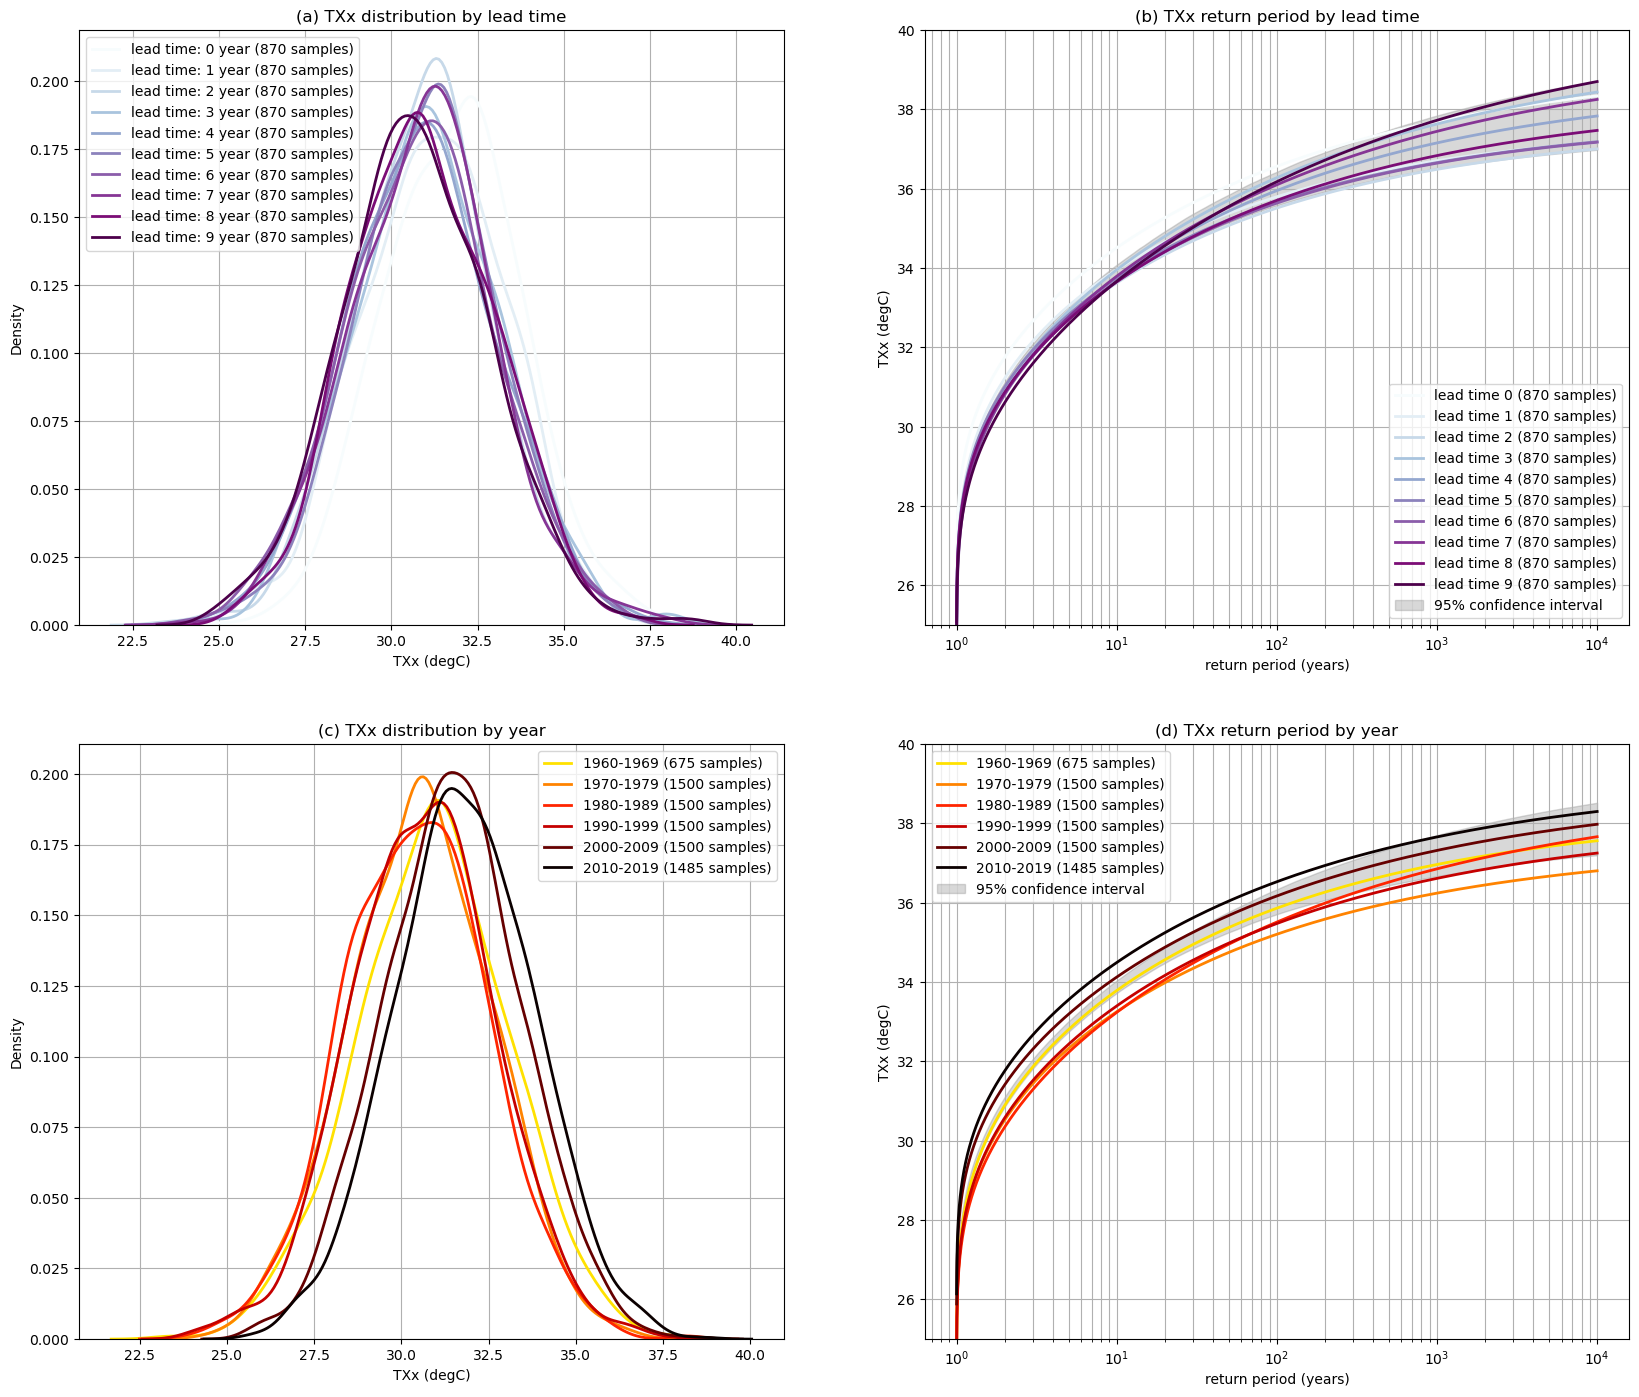

In [11]:
stability.create_plot(
    model_ds[var],
    metric,
    [1960, 1970, 1980, 1990, 2000, 2010],
    uncertainty=True,
    return_method='gev',
    units=f'{metric} ({units})',
    ylim=(dist_min, dist_max),
)

#### Independence

In [12]:
independence_ds = independence.run_tests(model_ds[var])

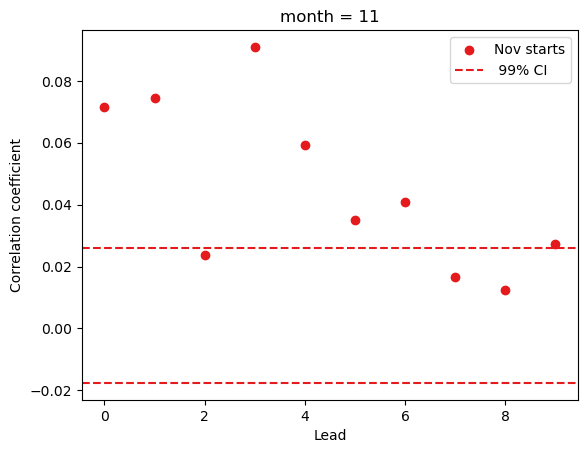

In [13]:
independence.point_plot(
    independence_ds,
    confidence_interval=0.99,
)

In [14]:
min_lead = 2

Drop lead times that aren't independent...

In [15]:
model_da_indep = model_ds[var].where(model_ds['lead_time'] >= min_lead)
model_da_indep = model_da_indep.dropna('lead_time')

In [16]:
model_da_indep_stacked = model_da_indep.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [17]:
model_da_indep_baseline = time_utils.select_time_period(model_da_indep, baseline_period)
model_da_indep_baseline_stacked = model_da_indep_baseline.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

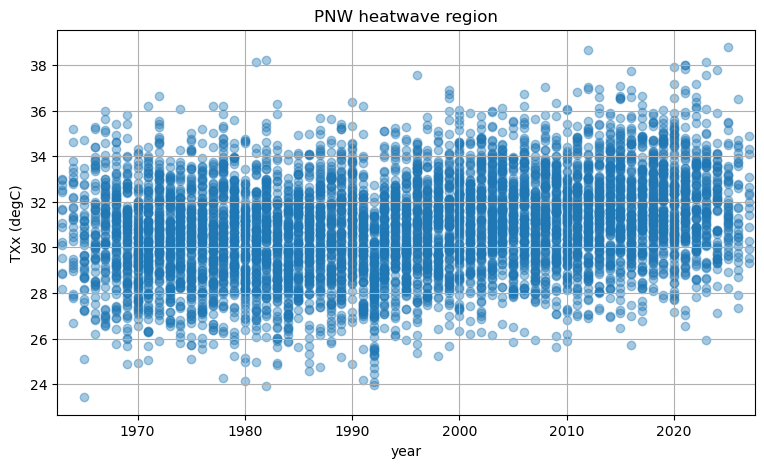

In [18]:
fig, ax = plt.subplots(figsize=[9, 5])
years = model_da_indep_stacked['time'].dt.year.values
unique_years = np.unique(model_da_indep_stacked.time.dt.year.values)

plt.scatter(
    years,
    model_da_indep_stacked.values,
    marker='o',
    color='tab:blue',
    alpha=0.4,
    label='raw data'
)
plt.xlim(unique_years[0] - 0.5, unique_years[-1] + 0.5)
plt.title(box_name)
plt.ylabel(f'{metric} ({units})')
plt.xlabel('year')
#plt.legend()
plt.grid()
plt.show()

#### Bias correction

In [19]:
bias = bias_correction.get_bias(
    model_da_indep,
    obs_ds[var],
    correction_method,
    time_rounding='A',
    time_period=baseline_period
)
print(bias)

<xarray.DataArray 'tasmax' (month: 1)> Size: 8B
dask.array<subtract, shape=(1,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 8B 11
Attributes:
    standard_name:           air_temperature
    long_name:               Daily Maximum Near-Surface Air Temperature
    comment:                 maximum near-surface (usually, 2 meter) air temp...
    units:                   °C
    cell_methods:            area: mean time: maximum
    cell_measures:           area: areacella
    history:                 2019-03-20T07:54:27Z altered by CMOR: Treated sc...
    units_metadata:          temperature: unknown
    climatological_period:   ['1970-01-01', '2017-12-30']
    bias_correction_method:  additive
    bias_correction_period:  1970-01-01-2017-12-30


In [20]:
bias_value = bias.values[0]
print(bias_value)

-0.059148136541008256


In [21]:
model_da_bc = bias_correction.remove_bias(model_da_indep, bias, correction_method)

In [22]:
model_da_bc = model_da_bc.compute()

In [23]:
model_da_bc_stacked = model_da_bc.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

In [24]:
model_da_bc_baseline = time_utils.select_time_period(model_da_bc, baseline_period)
model_da_bc_baseline_stacked = model_da_bc_baseline.stack({'sample': ['ensemble', 'init_date', 'lead_time']})

#### Similarity testing

In [25]:
def plot_dist(time_period='full'):
    """Plot distribution."""

    assert time_period in ['full', 'baseline']

    fig, ax = plt.subplots(figsize=[8, 5])
    xvals = np.arange(dist_min, dist_max, 0.1)

    if time_period == 'baseline':
        title = f'{box_name} - comparison period ({baseline_start}-{baseline_end})'
        model_da_indep_baseline.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
        model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_baseline_stacked.values, use_basinhopping=True)
        model_da_bc_baseline.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
        model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_baseline_stacked.values, use_basinhopping=True)
        obs_ds_baseline[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
        obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds_baseline[var].values, use_basinhopping=True)
    else:
        title = f'{box_name} - full timeseries'
        model_da_indep.plot.hist(bins=20, density=True, alpha=0.7, facecolor='tab:blue')
        model_raw_shape, model_raw_loc, model_raw_scale = eva.fit_gev(model_da_indep_stacked.values, use_basinhopping=True)
        model_da_bc.plot.hist(bins=50, density=True, alpha=0.7, facecolor='tab:orange')
        model_bc_shape, model_bc_loc, model_bc_scale = eva.fit_gev(model_da_bc_stacked.values, use_basinhopping=True)
        obs_ds[var].plot.hist(ax=ax, bins=50, density=True, facecolor='tab:gray', alpha=0.7)
        obs_shape, obs_loc, obs_scale = eva.fit_gev(obs_ds[var].values, use_basinhopping=True)
    
    model_raw_pdf = gev.pdf(xvals, model_raw_shape, model_raw_loc, model_raw_scale)
    plt.plot(xvals, model_raw_pdf, color='tab:blue', linewidth=4.0, label='model')
    
    model_bc_pdf = gev.pdf(xvals, model_bc_shape, model_bc_loc, model_bc_scale)
    plt.plot(xvals, model_bc_pdf, color='tab:orange', linewidth=4.0, label='model (corrected)')
    
    obs_pdf = gev.pdf(xvals, obs_shape, obs_loc, obs_scale)
    plt.plot(xvals, obs_pdf, color='tab:gray', linewidth=4.0, label='ERA5')
    
    plt.xlabel(f'{metric} ({units})')
    plt.ylabel('probability')
    plt.title(title)
    plt.xlim(dist_min, dist_max)
    plt.legend()
    plt.grid()
    plt.show()

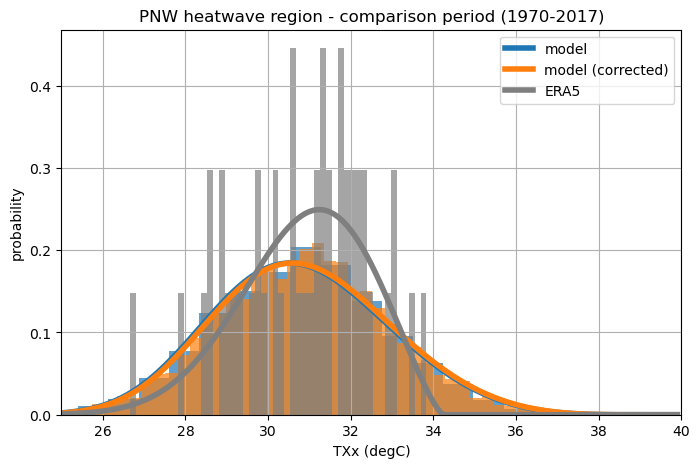

In [26]:
plot_dist(time_period='baseline')

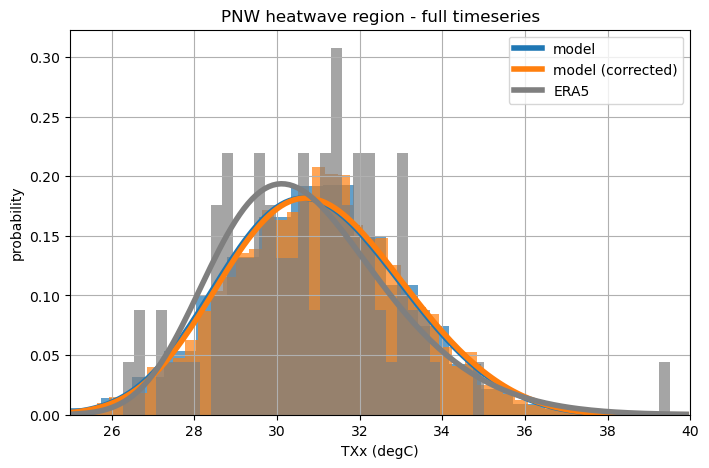

In [27]:
plot_dist(time_period='full')

Since the data has a strong trend with time, the similarity testing is conducted over the time period equally sampled by the observations and model (1970-2017).

In [28]:
#moments.create_plot(
#    model_da_indep_baseline,
#    obs_ds_baseline[var],
#    da_bc_fcst=model_da_bc_baseline,
#)

In [29]:
similarity_ds_indep = similarity.similarity_tests(model_da_indep_baseline, obs_ds_baseline[var])
print('KS score:', similarity_ds_indep['ks_statistic'].values)
print('KS p-value:', similarity_ds_indep['ks_pval'].values)
print('AD score:', similarity_ds_indep['ad_statistic'].values)
print('AD p-value:', similarity_ds_indep['ad_pval'].values)

KS score: 0.09674202
KS p-value: 0.7388342
AD score: 0.068241864
AD p-value: 0.25


In [30]:
similarity_ds_bc = similarity.similarity_tests(model_da_bc_baseline, obs_ds_baseline[var])
print('KS score:', similarity_ds_bc['ks_statistic'].values)
print('KS p-value:', similarity_ds_bc['ks_pval'].values)
print('AD score:', similarity_ds_bc['ad_statistic'].values)
print('AD p-value:', similarity_ds_bc['ad_pval'].values)

KS score: 0.10507535
KS p-value: 0.643287
AD score: -0.013550555
AD p-value: 0.25


p > 0.05 means that the null hypothesis (that the two samples are from the same population) cannot be rejected.

In [31]:
if similarity_ds_indep['ks_pval'].values > 0.05:
    model_da_samples_stacked = model_da_indep_stacked
    step_bias = f'No bias correction was applied to the {metric} values.'
elif similarity_ds_bc['ks_pval'].values > 0.05:
    model_da_samples_stacked = model_da_bc_stacked
    step_bias = f'Applied bias correction (additve mean scaling) to the {metric} values.'
else:
    raise Exception('Data fails similarity test before and after bias correction')

In [32]:
print(step_bias)

No bias correction was applied to the TXx values.


#### Process assessment

In [33]:
def ensemble_to_run(model_name, ensnum):
    """Map ensemble number to DCPP model run"""

    norcpm_dict = {
        1: 'r1i1p1f1',
        2: 'r1i2p1f1',
        3: 'r2i1p1f1',
        4: 'r2i2p1f1',
        5: 'r3i1p1f1',
        6: 'r3i2p1f1',
        7: 'r4i1p1f1',
        8: 'r4i2p1f1',
        9: 'r5i1p1f1',
        10: 'r5i2p1f1',
        11: 'r6i1p1f1',
        12: 'r6i2p1f1',
        13: 'r7i1p1f1',
        14: 'r7i2p1f1',
        15: 'r8i1p1f1',
        16: 'r8i2p1f1',
        17: 'r9i1p1f1',
        18: 'r9i2p1f1',
        19: 'r10i1p1f1',
        20: 'r10i2p1f1',
    }

    ecearth_dict = {
        1: 'r1i1p1f1',
        2: 'r2i1p1f1',
        3: 'r3i1p1f1',
        4: 'r4i1p1f1',
        5: 'r5i1p1f1',
        6: 'r6i1p1f1',
        7: 'r6i2p1f1',
        8: 'r7i1p1f1',
        9: 'r7i2p1f1',
        10: 'r8i1p1f1',
        11: 'r8i2p1f1',
        12: 'r9i1p1f1',
        13: 'r9i2p1f1',
        14: 'r10i1p1f1',
        15: 'r10i2p1f1',
    }

    if model_name == 'EC-Earth3':
        run = ecearth_dict[ensnum]
    elif model_name == 'NorCPM1':
        run = norcpm_dict[ensnum]
    else:
        ensemble_to_run = { 
            'BCC-CSM2-MR': f'r{ensnum}i1p1f1',
            'CanESM5': f'r{ensnum}i1p2f1',
            'CMCC-CM2-SR5': f'r{ensnum}i1p1f1',
            'HadGEM3-GC31-MM': f'r{ensnum}i1p1f2',
            'IPSL-CM6A-LR': f'r{ensnum}i1p1f1',
            'MIROC6': f'r{ensnum}i1p1f1',
            'MPI-ESM1-2-HR': f'r{ensnum}i1p1f1',
            'MRI-ESM2-0': f'r{ensnum}i1p1f1',
        }
        run = ensemble_to_run[model_name]

    return run
    

def find_dcpp_data(event_df_row, model_name):
    """Find DCPP data for one row of a dataframe of events."""

    init_adjustment = {
        'BCC-CSM2-MR': 0,
        'CanESM5': -1,
        'CMCC-CM2-SR5': -1,
        'EC-Earth3': -1,
        'IPSL-CM6A-LR': -1,
        'MIROC6': -1,
        'MPI-ESM1-2-HR': -1,
        'MRI-ESM2-0': -1,
        'NorCPM1': -1,
    }

    assert model_name in init_adjustment
    
    init_date = int(event_df_row['init_date'].strftime('%Y')) + init_adjustment[model_name]
    ensemble = int(event_df_row['ensemble']) + 1
    run = ensemble_to_run(model_name, ensemble)
    event_date = event_df_row['event_time']
    event_value = round(float(event_df_row[var]), 1)
    event_summary = f'{metric} of {event_value} on {event_date}: initialisation year {init_date}, ensemble member {run}'
    print(event_summary)
    var_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/day/{var}/*/*/*.nc')
    assert var_files
    psl_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/day/psl/*/*/*.nc')
    zg500_files = glob.glob(f'/g/data/oi10/replicas/CMIP6/DCPP/*/{model_name}/dcppA-hindcast/s{init_date}-{run}/AERday/zg500/*/*/*.nc')

    return var_files, psl_files, zg500_files, event_date, event_value, event_summary

In [67]:
def event_check(da, event_value):
    """Check the event value"""

    da_box = da.sel(lat=slice(box_lat0, box_lat1), lon=slice(box_lon0, box_lon1))
    da_box_mean = spatial_selection.aggregate(da_box, 'weighted_mean')
    
    np.testing.assert_approx_equal(float(da_box_mean[-1]) - bias_value, event_value, significant=1)
    

def get_start_date(event_date):
    """Get start date."""

    event_datetime = datetime.strptime(event_date, "%Y-%m-%d")
    start_datetime = event_datetime - timedelta(days=4)
    start_date = start_datetime.strftime("%Y-%m-%d")

    return start_date


def get_event_data(event_df_row, model_name):
    """Plot an event"""

    infiles_var, infiles_psl, infiles_zg500, event_date, event_value, event_summary = find_dcpp_data(event_df_row, model_name)
    dcpp_config = '/home/599/dbi599/unseen-projects/dataset_config/dataset_dcpp.yml'
    
    start_date = get_start_date(event_date)

    ds_var = fileio.open_dataset(infiles_var, metadata_file=dcpp_config)
    ds_var = ds_var.sel(
        time=slice(start_date, event_date),
        lat=slice(region_lat0 - 5, region_lat1 + 5),
        lon=slice(region_lon0 - 5, region_lon1 + 5),
    )
    da_var = general_utils.convert_units(ds_var[var], units)
    event_check(da_var, event_value)

    if infiles_psl:
        ds_psl = fileio.open_dataset(infiles_psl, metadata_file=dcpp_config)
        ds_psl = ds_psl.sel(
            time=slice(start_date, event_date),
            lat=slice(region_lat0 - 5, region_lat1 + 5),
            lon=slice(region_lon0 - 5, region_lon1 + 5),
        )
        da_psl = general_utils.convert_units(ds_psl['psl'], 'hPa')
    else:
        da_psl = None
    
    if infiles_zg500:
        ds_zg500 = fileio.open_dataset(infiles_zg500, metadata_file=dcpp_config)
        ds_zg500 = ds_zg500.sel(
            time=slice(start_date, event_date),
            lat=slice(region_lat0 - 5, region_lat1 + 5),
            lon=slice(region_lon0 - 5, region_lon1 + 5),
        )
        da_zg500 = ds_zg500['zg500']
    else:
        da_zg500 = None

    return da_var, da_psl, da_zg500

In [68]:
def plot_event(da_var, da_contour, contour_var):
    """Plot event."""

    assert contour_var in ['psl', 'zg500']
    
    fig = plt.figure(figsize=[15, 5])
    ax = fig.add_subplot(111, projection=map_proj)
    
    da_var.isel(time=4).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=var_cmap,
        levels=levels_dict[var],
        extend='both',
    #    cbar_kwargs={"label": label},
    )
    if type(da_contour) != type(None):
        lines = da_contour.isel(time=4).plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=levels_dict[contour_var],
            colors=["0.3"]
        )
        ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
    
    ax.plot(
        [box_lon0, box_lon0, box_lon1, box_lon1, box_lon0],
        [box_lat1, box_lat0, box_lat0, box_lat1, box_lat1],
        transform=ccrs.PlateCarree(),
        color='green',
    )   
    ax.coastlines()
    #ax.set_extent([180, 300, 30, 70], crs=ccrs.PlateCarree(central_longitude=0))
    ax.add_feature(cartopy.feature.BORDERS)
    ax.gridlines(linestyle="--", draw_labels=True)
    
    plt.show()

In [69]:
model_da_samples_stacked_df = model_da_samples_stacked.to_dataframe()
nsamples = len(model_da_samples_stacked_df)
model_da_samples_stacked_df.index = range(1, nsamples + 1)
model_da_samples_stacked_df_sorted = model_da_samples_stacked_df.sort_values(by=[var], ascending=False)
model_da_samples_stacked_df_sorted.head(n=10)

,event_time,time,ensemble,init_date,lead_time,tasmax
6944,2025-07-30,2025-11-01 00:00:00,14,2016-11-01 00:00:00,9,38.776842
3128,2012-08-10,2012-11-01 00:00:00,6,2003-11-01 00:00:00,9,38.649396
118,1982-08-06,1982-11-01 00:00:00,0,1975-11-01 00:00:00,7,38.217531
4144,2023-08-19,2023-11-01 00:00:00,8,2014-11-01 00:00:00,9,38.148110
2922,1981-08-16,1981-11-01 00:00:00,6,1978-11-01 00:00:00,3,38.141396
4170,2021-08-01,2021-11-01 00:00:00,8,2018-11-01 00:00:00,3,38.004260
6026,2021-08-09,2021-11-01 00:00:00,12,2018-11-01 00:00:00,3,37.979840
5090,2020-08-21,2020-11-01 00:00:00,10,2017-11-01 00:00:00,3,37.895452
6954,2021-08-02,2021-11-01 00:00:00,14,2018-11-01 00:00:00,3,37.822167
5094,2024-08-16,2024-11-01 00:00:00,10,2017-11-01 00:00:00,7,37.780492


In [70]:
nsamples = len(model_da_samples_stacked_df)
print(f'Total number of samples: {nsamples}')

Total number of samples: 6960


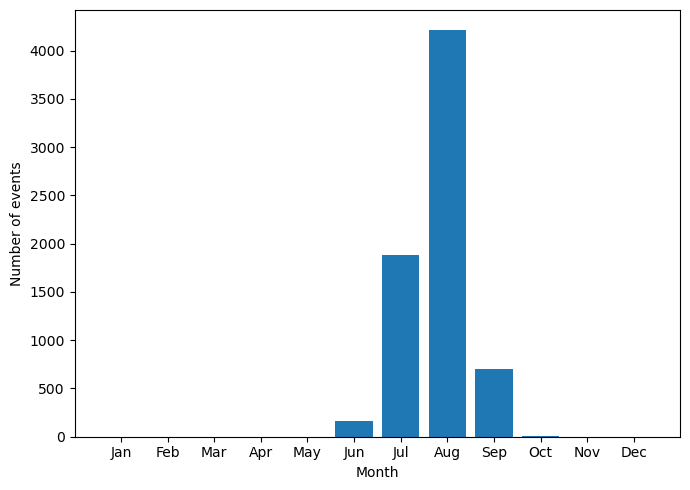

In [71]:
process_utils.plot_event_seasonality(model_da_samples_stacked, core_dim='sample')

TXx of 38.8 on 2025-07-30: initialisation year 2015, ensemble member r10i2p1f1


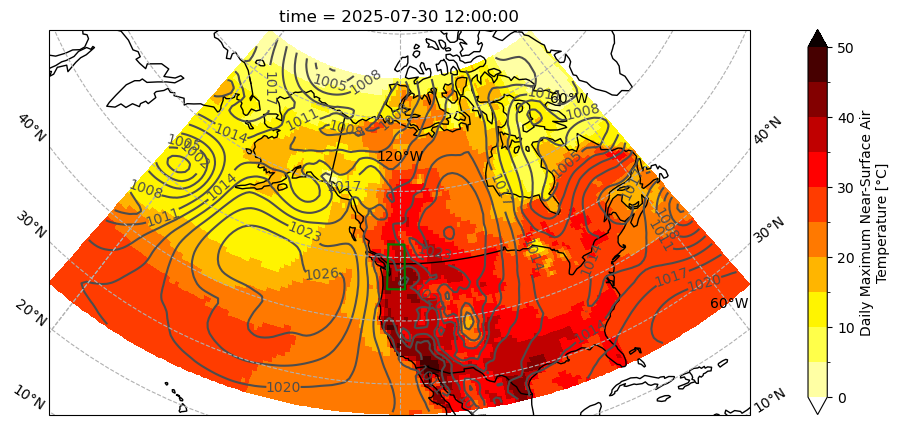

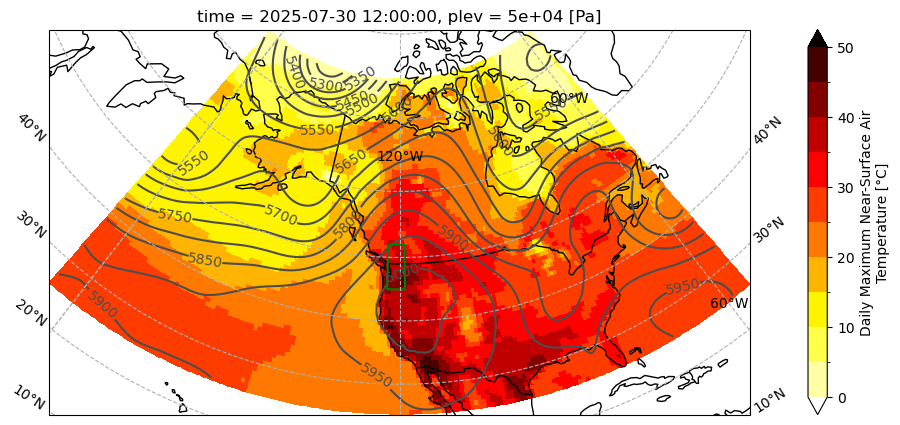

TXx of 38.6 on 2012-08-10: initialisation year 2002, ensemble member r6i2p1f1


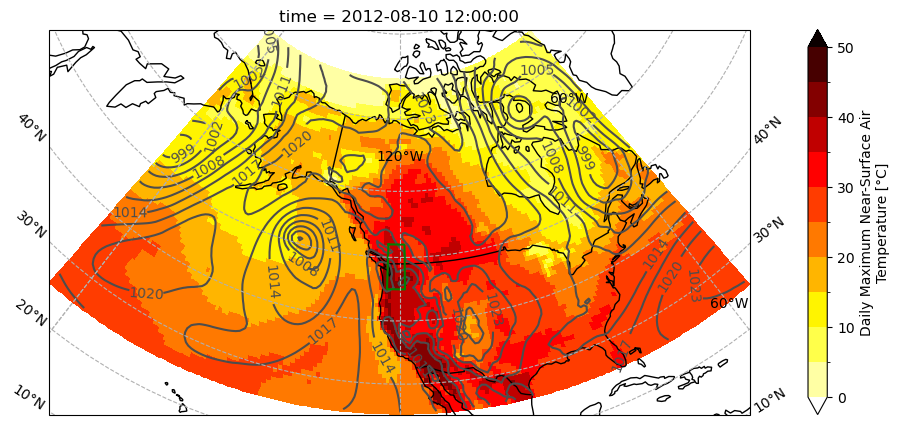

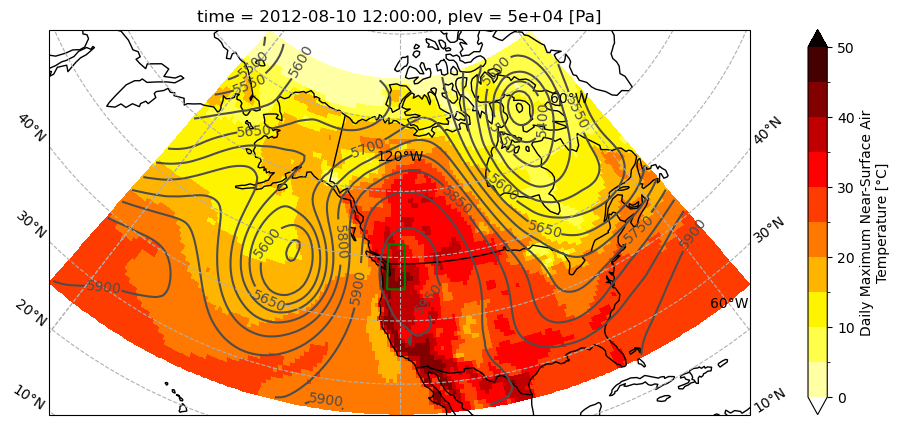

TXx of 38.2 on 1982-08-06: initialisation year 1974, ensemble member r1i1p1f1


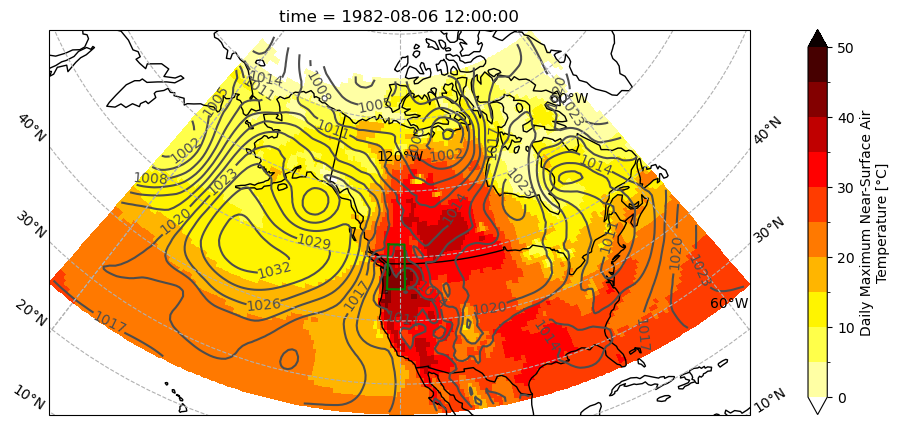

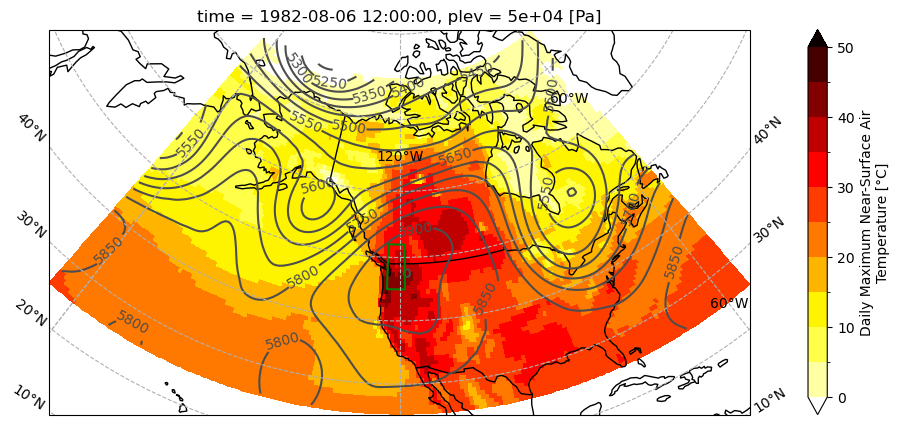

TXx of 38.1 on 2023-08-19: initialisation year 2013, ensemble member r7i2p1f1


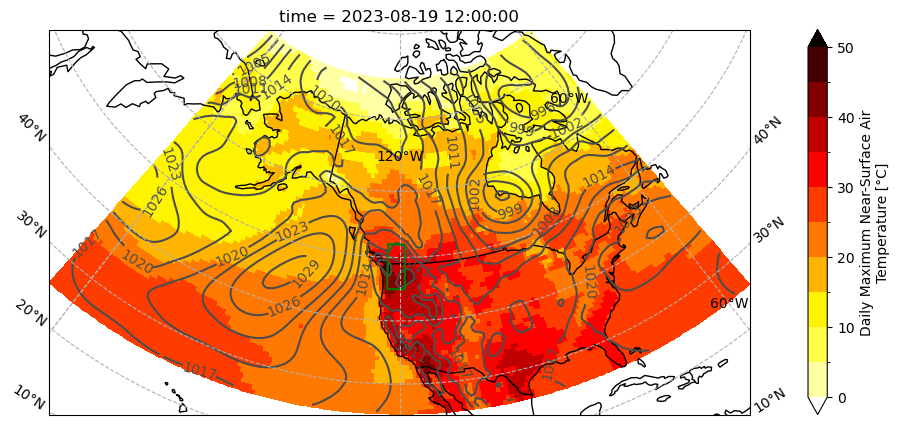

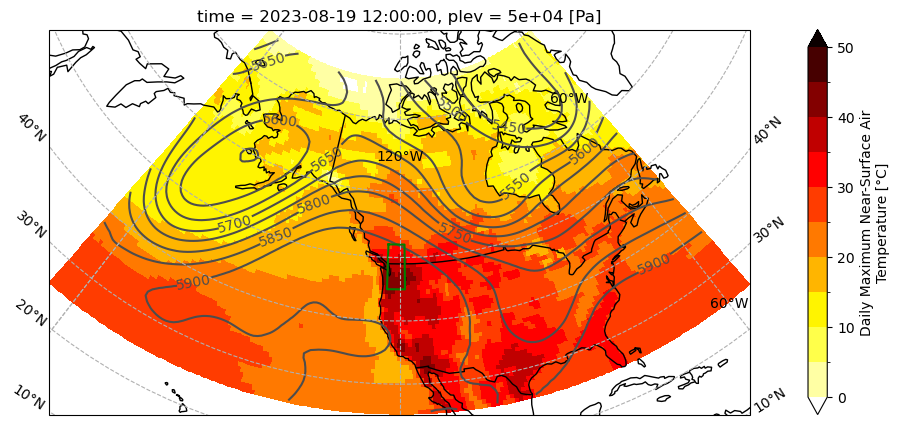

TXx of 38.1 on 1981-08-16: initialisation year 1977, ensemble member r6i2p1f1


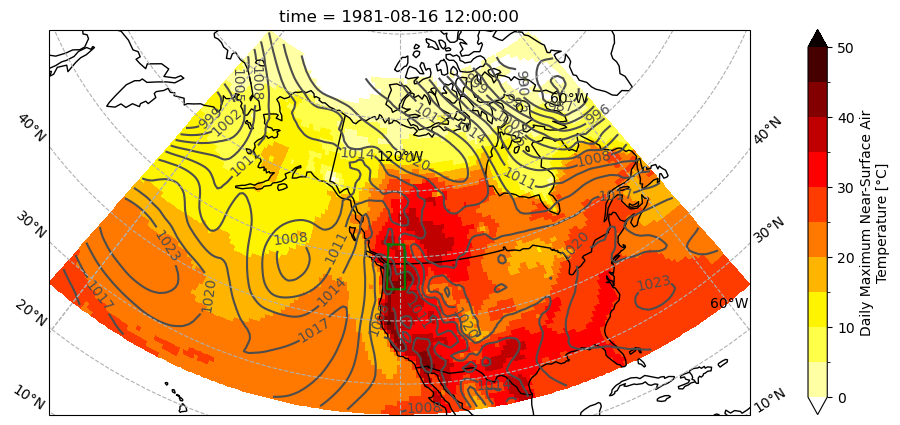

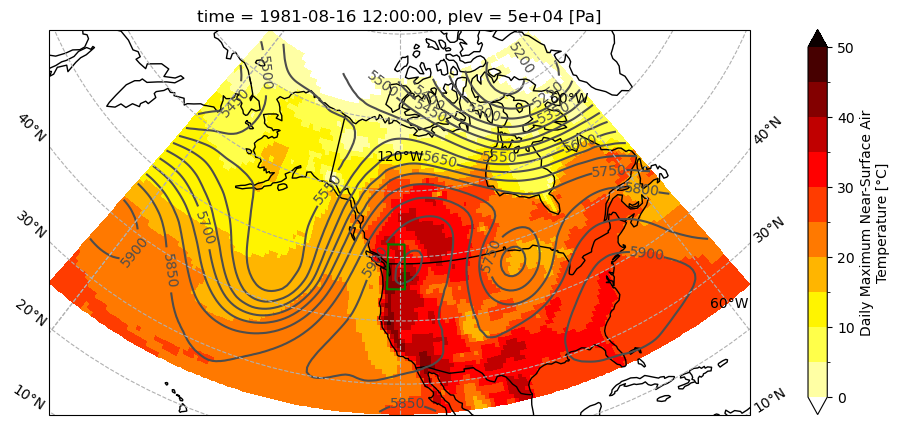

TXx of 38.0 on 2021-08-01: initialisation year 2017, ensemble member r7i2p1f1


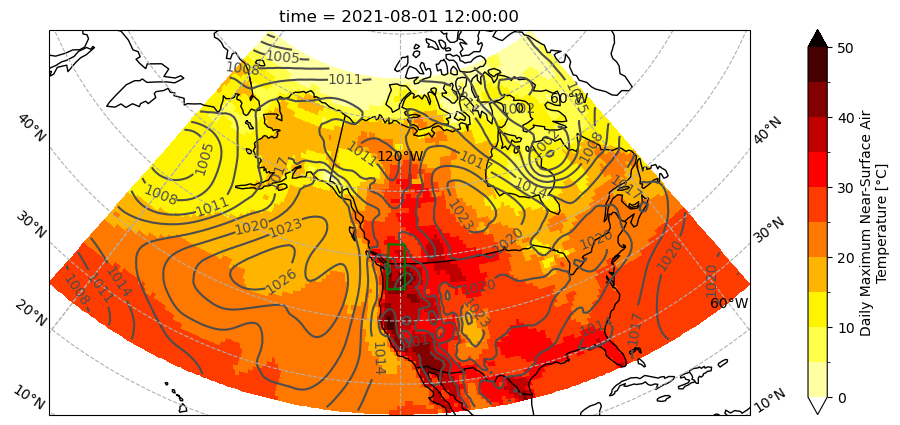

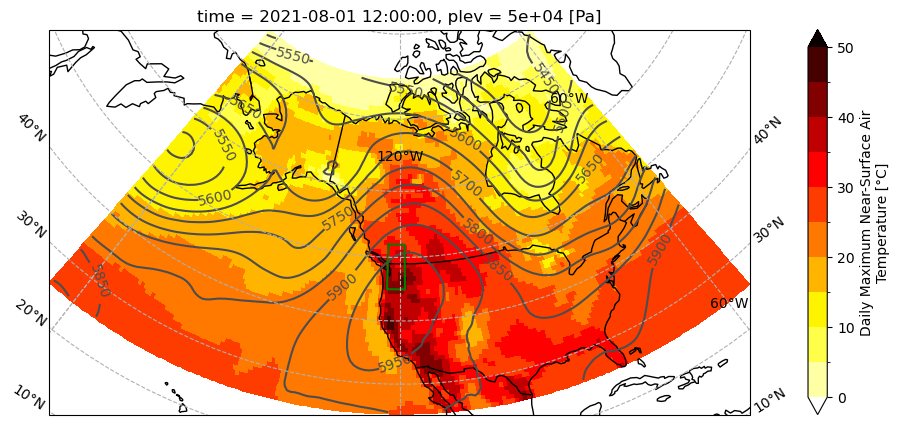

TXx of 38.0 on 2021-08-09: initialisation year 2017, ensemble member r9i2p1f1


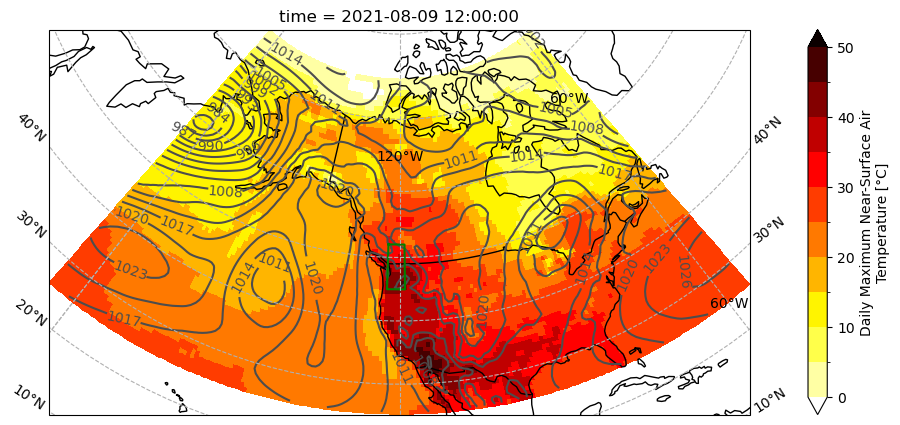

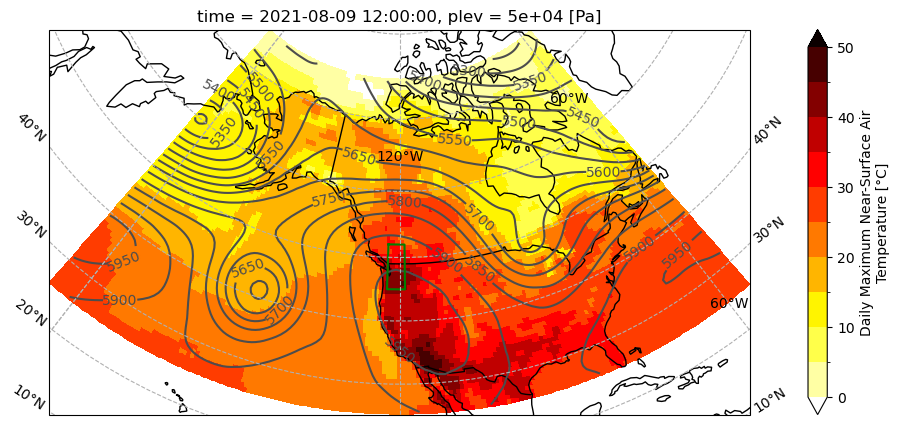

TXx of 37.9 on 2020-08-21: initialisation year 2016, ensemble member r8i2p1f1


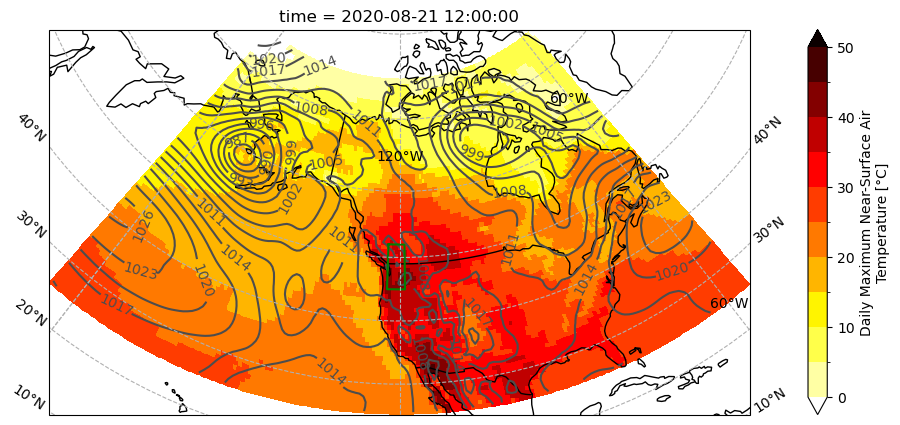

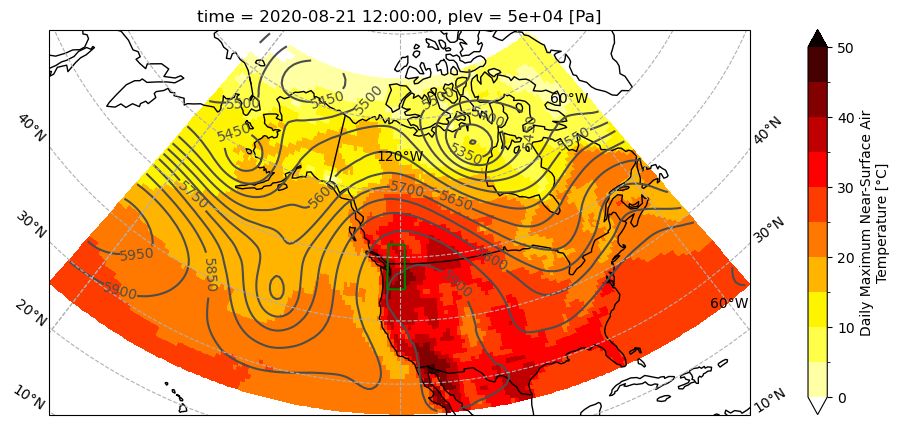

TXx of 37.8 on 2021-08-02: initialisation year 2017, ensemble member r10i2p1f1


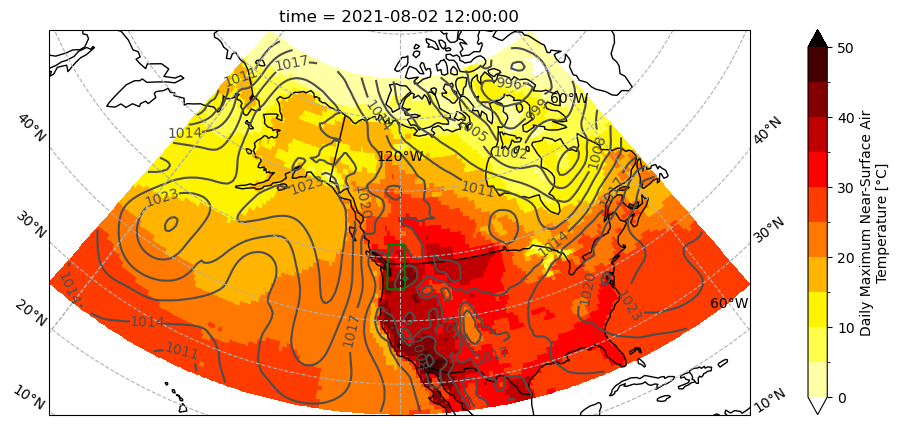

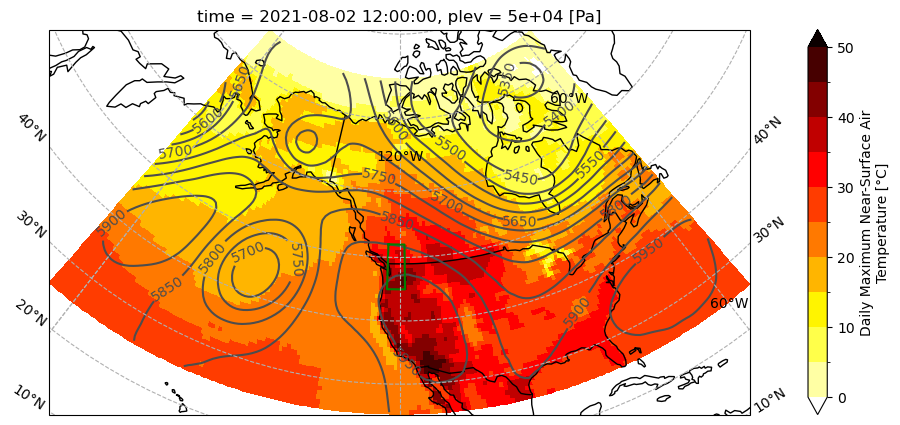

TXx of 37.8 on 2024-08-16: initialisation year 2016, ensemble member r8i2p1f1


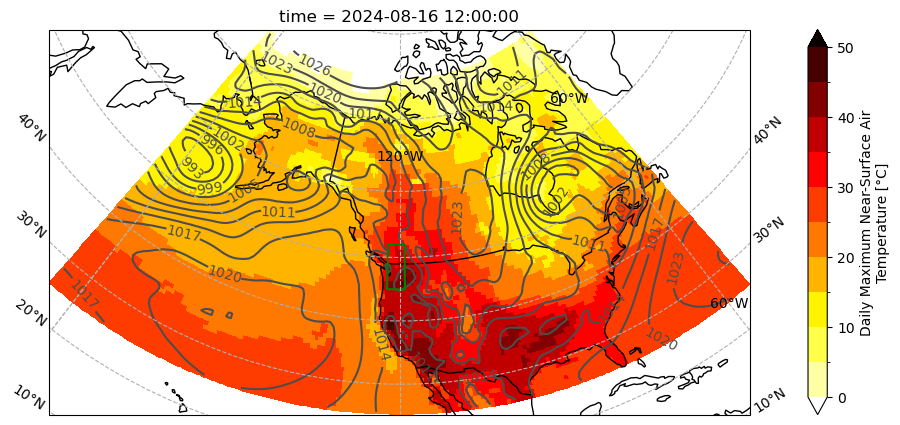

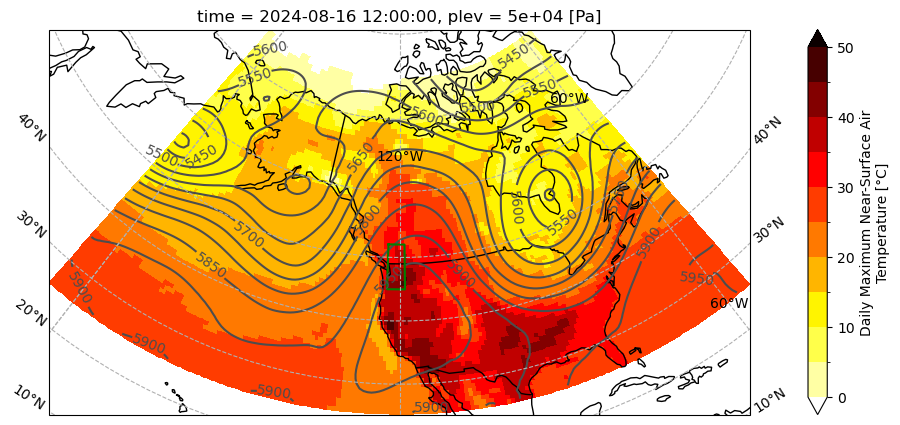

In [72]:
da_var_dict = {}
da_psl_dict = {}
da_zg500_dict = {}
for rank in range(10):
    number = model_da_samples_stacked_df_sorted.iloc[rank].name
    da_var_dict[number], da_psl_dict[number], da_zg500_dict[number] = get_event_data(
        model_da_samples_stacked_df_sorted.iloc[rank], model
    )
    plot_event(da_var_dict[number], da_psl_dict[number], 'psl')
    plot_event(da_var_dict[number], da_zg500_dict[number], 'zg500')

## Results

#### Non-stationary GEV

In [40]:
#AIC/BIC/LRT test to see if it's worth modelling the scale trend
daparams_list = [eva.fit_gev(
    model_da_samples_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_samples_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=scale1,
).values for scale1 in [0, None]]

data = model_da_samples_stacked.values
covariate = model_da_samples_stacked['time'].dt.year.values
nll_1 = eva._gev_nllf(daparams_list[0], data, covariate)
nll_2 = eva._gev_nllf(daparams_list[1], data, covariate)
result = eva.check_gev_relative_fit(data, nll_1, nll_2, test='bic', n_params=[4,5])
print('better to include the scale trend parameter:', result)

better to include the scale trend parameter: False


In [41]:
daparams = eva.fit_gev(
    model_da_samples_stacked,
    core_dim="sample",
    stationary=False,
    covariate=model_da_samples_stacked['time'].dt.year,
    use_basinhopping=True,
    scale1=None,
)

In [42]:
for param, value in zip(daparams.dparams.values, daparams.values):
    print(param, value)

c 0.2274137042071866
location_0 -35.64730998138386
location_1 0.03297428678284423
scale_0 2.0059682892435133
scale_1 0.0


In [43]:
return_period = float(eva.get_return_period(obs_max_event, daparams, covariate=2021).values)

In [44]:
# parametric uncertainty estimate
n_bootstraps = 1000
shape, loc, scale = eva.unpack_gev_params(daparams, 2021)
sample_size = len(model_da_samples_stacked)
boot_samples = []
for i in range(n_bootstraps):
    boot_data = gev.rvs(float(shape), loc=float(loc), scale=float(scale), size=sample_size)
    boot_gev_params = eva.fit_gev(boot_data)
    boot_return_period = eva.get_return_period(obs_max_event, boot_gev_params)
    boot_samples.append(boot_return_period)
ci05 = np.percentile(boot_samples, 5)
ci16 = np.percentile(boot_samples, 16)
ci84 = np.percentile(boot_samples, 84)
ci95 = np.percentile(boot_samples, 95)

In [45]:
print(f'The return period of a {obs_max_event:.2f} {units} event in 2021 is {return_period:.0f} years.')
print(f'The 5-95% confidence interval is {ci05:.0f} to {ci95:.0f} years.')
print(f'The 16-84% confidence interval is {ci16:.0f} to {ci84:.0f} years.')

The return period of a 39.51 degC event in 2021 is 2873332 years.
The 5-95% confidence interval is 167835 to nan years.
The 16-84% confidence interval is 384416 to 1106837844 years.


In [46]:
for year in np.arange(1960, 2030):
    rp = float(eva.get_return_period(obs_max_event, daparams, covariate=year).values)
    print(f'The return period of a {obs_max_event:.2f} {units} event in {year} is {rp:.0f} years.')

The return period of a 39.51 degC event in 1960 is inf years.
The return period of a 39.51 degC event in 1961 is inf years.
The return period of a 39.51 degC event in 1962 is inf years.
The return period of a 39.51 degC event in 1963 is inf years.
The return period of a 39.51 degC event in 1964 is inf years.
The return period of a 39.51 degC event in 1965 is inf years.
The return period of a 39.51 degC event in 1966 is inf years.
The return period of a 39.51 degC event in 1967 is inf years.
The return period of a 39.51 degC event in 1968 is inf years.
The return period of a 39.51 degC event in 1969 is inf years.
The return period of a 39.51 degC event in 1970 is inf years.
The return period of a 39.51 degC event in 1971 is inf years.
The return period of a 39.51 degC event in 1972 is inf years.
The return period of a 39.51 degC event in 1973 is inf years.
The return period of a 39.51 degC event in 1974 is inf years.
The return period of a 39.51 degC event in 1975 is inf years.
The retu

## Supporting data

In [47]:
ecmwf_attrs = {}
ecmwf_attrs['tasmax'] = {
    'name': 'mx2t',
    'units': 'K',
    'long_name': 'Maximum temperature at 2 metres since previous post-processing',
}
ecmwf_attrs['psl'] = {
    'name': 'msl',
    'units': 'Pa',
    'long_name': 'Mean sea level pressure',
}
ecmwf_attrs['zg500'] = {
    'name': 'gh500',
    'units': 'm',
    'long_name': 'Geopotential height at 500 hPa',
}

### Tier 2 data

In [48]:
numbers = model_da_samples_stacked_df.index.values
da1 = xr.DataArray(
    data=np.round(model_da_samples_stacked_df[var].values, 2),
    coords={'number': numbers,},
    name=metric,
    attrs = {
        'long_name': metric_long,
        'units': units,
    }
)
da1 = general_utils.convert_units(da1, ecmwf_attrs[var]['units'])
try:
    del da1.attrs['units_metadata']
except ValueError:
    pass

event_times = [time_utils.str_to_cftime(t) for t in model_da_samples_stacked_df['event_time'].values]
da2 = xr.DataArray(
    data=event_times,
    coords={'number': numbers,},
    name='event_date',
    attrs = {
        'long_name': 'Event date',
    }
)
    
output_ds = xr.merge([da1, da2])
output_ds.attrs = global_attrs
output_ds.attrs['data_tier'] = 'tier2'
step_download = 'Downloaded daily maximum surface temprature data (tasmax).'
step_spatial_selection = 'Selected the PNW domain (45-52N, 119-123W).'
step_spatial_aggregation = 'Computed the cosine-latitude-weighted spatial mean.'
step_temporal_aggregation = 'Resampled to annual maxima.'
step_independence = f'Dropped lead times that are not independent (< {min_lead} years).'
output_ds.attrs['processing'] = f'{step_download} {step_spatial_selection} {step_spatial_aggregation} {step_temporal_aggregation} {step_independence} {step_bias}'
output_ds['number'].attrs['long_name'] = 'Sample number'

fname = f'{outdir}/CSIRO_UNSEEN_tier2_{model}.nc'
encoding = get_encoding(output_ds)
encoding['event_date']['units'] = 'days since 1960-01-01'
output_ds.to_netcdf(fname, encoding=encoding)
print(fname)

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/CSIRO_UNSEEN_tier2_EC-Earth3.nc


### Tier 3 data

#### 5-day sequences

In [49]:
def ceaa_format(da, variable, number=None, sequence=False):
    """Modify an array so if conforms with the requested CEAA format"""

    try:
        da = da.drop_vars('height')
    except ValueError:
        pass

    try:
        da = da.drop_vars('plev')
    except ValueError:
        pass

    da = general_utils.convert_units(da, ecmwf_attrs[variable]['units'])

    da = da.rename({'lat': 'latitude', 'lon': 'longitude'})
    da.name = ecmwf_attrs[variable]['name']
    da.attrs = {}
    da.attrs['long_name'] = ecmwf_attrs[variable]['long_name']
    da.attrs['units'] = ecmwf_attrs[variable]['units']

    if number:
        da['number'] = number
        da['number'].attrs['long_name'] = 'Sample number'
    if sequence:
        da['time'] = [-4, -3, -2, -1, 0]
        da['time'].attrs['long_name'] = "Time relative to event"
        da['time'].attrs['units'] = 'days'

    return da

In [73]:
da_var_list = []
da_psl_list = []
da_zg500_list = []
skip_vars = []
for number, da_var in da_var_dict.items():
    da_var_ceaa = ceaa_format(da_var, var, number=number, sequence=True)
    da_var_list.append(da_var_ceaa)
    
    da_psl = da_psl_dict[number]
    if type(da_psl) == type(None):
        print(f'missing psl data for sample number {number}') 
        da_psl_ceaa = da_var_ceaa * np.nan
        da_psl_ceaa.name = ecmwf_attrs['psl']['name']
        da_psl_ceaa.attrs['long_name'] = ecmwf_attrs['psl']['long_name']
        da_psl_ceaa.attrs['units'] = ecmwf_attrs['psl']['units']
        skip_vars.append('msl')
    else:
        da_psl_ceaa = ceaa_format(da_psl, 'psl', number=number, sequence=True)
    da_psl_list.append(da_psl_ceaa)

    da_zg500 = da_zg500_dict[number]
    if type(da_zg500) == type(None):
        print(f'missing zg500 data for sample number {number}') 
        da_zg500_ceaa = da_var_ceaa * np.nan
        da_zg500_ceaa.name = ecmwf_attrs['zg500']['name']
        da_zg500_ceaa.attrs['long_name'] = ecmwf_attrs['zg500']['long_name']
        da_zg500_ceaa.attrs['units'] = ecmwf_attrs['zg500']['units']
        skip_vars.append('gh500')
    else:
        da_zg500_ceaa = ceaa_format(da_zg500, 'zg500', number=number, sequence=True)
    da_zg500_list.append(da_zg500_ceaa)

ds_var = xr.concat(da_var_list, dim='number')
ds_psl = xr.concat(da_psl_list, dim='number')
ds_zg500 = xr.concat(da_zg500_list, dim='number')
skip_vars = list(set(skip_vars))

ds = xr.merge([ds_var, ds_psl, ds_zg500])
ds.attrs = global_attrs
ds.attrs['data_tier'] = 'tier3'
step_download_spatial_select = 'Downloaded daily maximum surface temperature (tasmax), daily mean sea level pressure (psl) and 500hPa geopotential height (zg500) data over the 30-70N, 60-180W domain.' 
step_tstep_select = f'Selected the five days leading up to and including the day of the top ten most extreme {metric} events.'
ds.attrs['processing'] = f'{step_download_spatial_select} {step_tstep_select}'
encoding = get_encoding(ds, skip_vars=skip_vars)
outfname = f'{outdir}/CSIRO_UNSEEN_tier3_{model}_5day.nc'
ds.to_netcdf(outfname, encoding=encoding)
print(outfname)

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/CSIRO_UNSEEN_tier3_EC-Earth3_5day.nc


#### Climatologies

They ask for the June-July climatology for the 1991-2020 period.

In [51]:
ds_annual_dict = {}
ds_annual_dict[var] = fileio.open_dataset(annual_infile_dict[var])
ds_annual_dict['psl'] = fileio.open_dataset(annual_infile_dict['psl'])
ds_annual_dict['zg500'] = fileio.open_dataset(annual_infile_dict['zg500'])

In [52]:
def calc_clim(ds, clim_var):
    """Calculate climatology"""

    ds = ds.compute()
    ds[var] = general_utils.convert_units(ds[clim_var], units_dict[clim_var])
    ds = array_handling.reindex_forecast(ds)
    da_baseline = ds[clim_var].sel(time=slice('1991-01-01', '2020-12-31'))
    da_clim = da_baseline.mean(dim=['time', 'init_date', 'ensemble'])
    da_clim.attrs['units'] = units_dict[clim_var]

    return da_clim

In [53]:
clim_dict = {}
clim_dict[var] = calc_clim(ds_annual_dict[var], var)
clim_dict['psl'] = calc_clim(ds_annual_dict['psl'], 'psl')
clim_dict['zg500'] = calc_clim(ds_annual_dict['zg500'], 'zg500')

In [54]:
def plot_climatology(contour_var):
    """Plot the climatology"""

    fig = plt.figure(figsize=[15, 5])
    ax = fig.add_subplot(111, projection=map_proj)

    clim_dict[var].plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=var_cmap,
        levels=levels_dict[var],
    )
    lines = clim_dict[contour_var].plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=levels_dict[contour_var],
        colors=["0.3"]
    )
    ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
    
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    ax.gridlines(linestyle="--", draw_labels=True)
    
    plt.title('1991-2020 climatology (June-July)')
    plt.show()

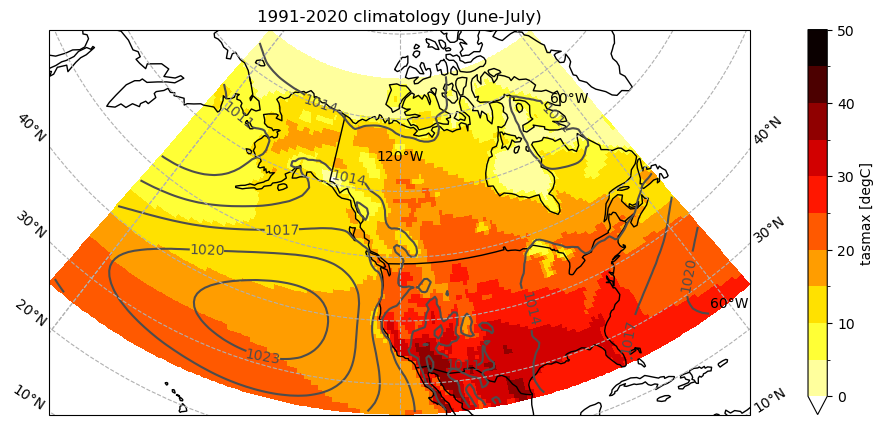

In [55]:
plot_climatology('psl')

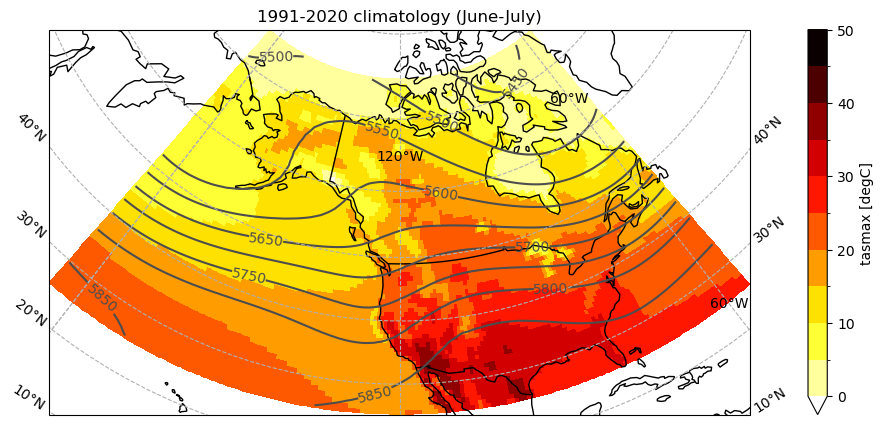

In [56]:
plot_climatology('zg500')

In [57]:
da_var_clim = ceaa_format(clim_dict[var], var)
da_psl_clim = ceaa_format(clim_dict['psl'], 'psl')
da_zg500_clim = ceaa_format(clim_dict['zg500'], 'zg500')

In [58]:
ds = xr.merge([da_var_clim, da_psl_clim, da_zg500_clim])
ds.attrs = global_attrs
ds.attrs['data_tier'] = 'tier3'
step_clim = 'Calculated the 1991-2020 climatology (June-July).'
ds.attrs['processing'] = ''f'{step_download_spatial_select} {step_clim}'
encoding = get_encoding(ds)
outfname = f'{outdir}/CSIRO_UNSEEN_tier3_{model}_climatology.nc'
ds.to_netcdf(outfname, encoding=encoding)
print(outfname)

/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/CSIRO_UNSEEN_tier3_EC-Earth3_climatology.nc
